In [1]:
import pandas as pd
import numpy as np

from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LinearRegression

In [2]:
df = pd.read_csv(r"C:\Users\Abhishek Verma\Downloads\train.csv")

In [3]:
df.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [4]:
num_cols = df.select_dtypes(include=np.number).columns
df[num_cols] = df[num_cols].fillna(df[num_cols].mean())

cat_cols = df.select_dtypes(include='object').columns
df[cat_cols] = df[cat_cols].fillna(df[cat_cols].mode().iloc[0])

In [5]:
df = df.drop_duplicates()

In [6]:
le = LabelEncoder()

df[cat_cols] = df[cat_cols].apply(le.fit_transform)

In [7]:
X = df.drop("SalePrice", axis=1)
y = df["SalePrice"]

In [8]:
from sklearn.model_selection import train_test_split

In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [10]:
model = LinearRegression()

model.fit(X, y)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [11]:
model = LinearRegression()

model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [12]:
y_pred = model.predict(X_test)

In [13]:
predicted_price = model.predict(X)

print(predicted_price[:10])

[220663.17391956 192408.81467408 222250.25687527 170271.67625207
 287803.68305752 171136.87001403 292091.5323803  231504.14497845
 157968.20638839 121227.07776101]


In [14]:
result = pd.DataFrame({"Actual Price": y,"Predicted Price": predicted_price})

print(result.head(10))

   Actual Price  Predicted Price
0        208500    220663.173920
1        181500    192408.814674
2        223500    222250.256875
3        140000    170271.676252
4        250000    287803.683058
5        143000    171136.870014
6        307000    292091.532380
7        200000    231504.144978
8        129900    157968.206388
9        118000    121227.077761


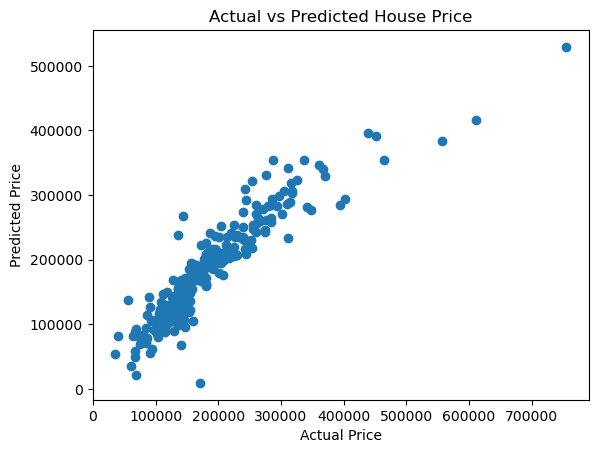

In [15]:
import matplotlib.pyplot as plt

plt.scatter(y_test, y_pred)

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted House Price")

plt.show()